In [1]:
# download again (optional)
!wget -nc https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip

# unzip without asking anything
!unzip -o UCI\ HAR\ Dataset.zip


--2026-03-25 09:00:32--  https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘UCI HAR Dataset.zip’

UCI HAR Dataset.zip     [    <=>             ]  58.17M  73.6MB/s    in 0.8s    

2026-03-25 09:00:33 (73.6 MB/s) - ‘UCI HAR Dataset.zip’ saved [60999314]

Archive:  UCI HAR Dataset.zip
   creating: UCI HAR Dataset/
  inflating: UCI HAR Dataset/.DS_Store  
   creating: __MACOSX/
   creating: __MACOSX/UCI HAR Dataset/
  inflating: __MACOSX/UCI HAR Dataset/._.DS_Store  
  inflating: UCI HAR Dataset/activity_labels.txt  
  inflating: __MACOSX/UCI HAR Dataset/._activity_labels.txt  
  inflating: UCI HAR Dataset/features.txt  
  inflating: __MACOSX/UCI HAR Dataset/._features.txt  
  inflating: UCI HAR Dataset/features_info.t

In [2]:
# importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ml libraries
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

sns.set_style("whitegrid")


In [3]:
# loading feature names
features = pd.read_csv("UCI HAR Dataset/features.txt",
                       sep=r"\s+", header=None, names=["index", "feature"])

# FIX: make feature names unique
feature_names = features["feature"].astype(str) + "_" + features["index"].astype(str)

# loading train data
X_train = pd.read_csv("UCI HAR Dataset/train/X_train.txt",
                      sep=r"\s+", header=None, names=feature_names)

y_train = pd.read_csv("UCI HAR Dataset/train/y_train.txt",
                      sep=r"\s+", header=None, names=["Activity"])

subject_train = pd.read_csv("UCI HAR Dataset/train/subject_train.txt",
                            sep=r"\s+", header=None, names=["subject"])

# combining train data
train = pd.concat([X_train, y_train, subject_train], axis=1)

# loading test data
X_test = pd.read_csv("UCI HAR Dataset/test/X_test.txt",
                     sep=r"\s+", header=None, names=feature_names)

y_test = pd.read_csv("UCI HAR Dataset/test/y_test.txt",
                     sep=r"\s+", header=None, names=["Activity"])

subject_test = pd.read_csv("UCI HAR Dataset/test/subject_test.txt",
                           sep=r"\s+", header=None, names=["subject"])

# combining test data
test = pd.concat([X_test, y_test, subject_test], axis=1)

# merging full dataset
df = pd.concat([train, test], axis=0)

df.head()

,tBodyAcc-mean()-X_1,tBodyAcc-mean()-Y_2,tBodyAcc-mean()-Z_3,tBodyAcc-std()-X_4,tBodyAcc-std()-Y_5,tBodyAcc-std()-Z_6,tBodyAcc-mad()-X_7,tBodyAcc-mad()-Y_8,tBodyAcc-mad()-Z_9,tBodyAcc-max()-X_10,...,fBodyBodyGyroJerkMag-kurtosis()_554,"angle(tBodyAccMean,gravity)_555","angle(tBodyAccJerkMean),gravityMean)_556","angle(tBodyGyroMean,gravityMean)_557","angle(tBodyGyroJerkMean,gravityMean)_558","angle(X,gravityMean)_559","angle(Y,gravityMean)_560","angle(Z,gravityMean)_561",Activity,subject
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,5,1
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,5,1
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,5,1
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,5,1
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,5,1


In [4]:
# checking size and info of dataset
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (10299, 563)
<class 'pandas.core.frame.DataFrame'>
Index: 10299 entries, 0 to 2946
Columns: 563 entries, tBodyAcc-mean()-X_1 to subject
dtypes: float64(561), int64(2)
memory usage: 44.3 MB


,tBodyAcc-mean()-X_1,tBodyAcc-mean()-Y_2,tBodyAcc-mean()-Z_3,tBodyAcc-std()-X_4,tBodyAcc-std()-Y_5,tBodyAcc-std()-Z_6,tBodyAcc-mad()-X_7,tBodyAcc-mad()-Y_8,tBodyAcc-mad()-Z_9,tBodyAcc-max()-X_10,...,fBodyBodyGyroJerkMag-kurtosis()_554,"angle(tBodyAccMean,gravity)_555","angle(tBodyAccJerkMean),gravityMean)_556","angle(tBodyGyroMean,gravityMean)_557","angle(tBodyGyroJerkMean,gravityMean)_558","angle(X,gravityMean)_559","angle(Y,gravityMean)_560","angle(Z,gravityMean)_561",Activity,subject
count,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,...,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000
mean,0.274347,-0.017743,-0.108925,-0.607784,-0.510191,-0.613064,-0.633593,-0.525697,-0.614989,-0.466732,...,-0.617700,0.007705,0.002648,0.017683,-0.009219,-0.496522,0.063255,-0.054284,3.624624,16.146422
std,0.067628,0.037128,0.053033,0.438694,0.500240,0.403657,0.413333,0.484201,0.399034,0.538707,...,0.308796,0.336591,0.447364,0.616188,0.484770,0.511158,0.305468,0.268898,1.743695,8.679067
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,1.000000
25%,0.262625,-0.024902,-0.121019,-0.992360,-0.976990,-0.979137,-0.993293,-0.977017,-0.979064,-0.935788,...,-0.841847,-0.124694,-0.287031,-0.493108,-0.389041,-0.817288,0.002151,-0.131880,2.000000,9.000000
50%,0.277174,-0.017162,-0.108596,-0.943030,-0.835032,-0.850773,-0.948244,-0.843670,-0.845068,-0.874825,...,-0.703402,0.008146,0.007668,0.017192,-0.007186,-0.715631,0.182028,-0.003882,4.000000,17.000000
75%,0.288354,-0.010625,-0.097589,-0.250293,-0.057336,-0.278737,-0.302033,-0.087405,-0.288149,-0.014641,...,-0.487981,0.149005,0.291490,0.536137,0.365996,-0.521503,0.250790,0.102970,5.000000,24.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,30.000000


In [5]:
# checking for missing values
df.isnull().sum()

,0
tBodyAcc-mean()-X_1,0
tBodyAcc-mean()-Y_2,0
tBodyAcc-mean()-Z_3,0
tBodyAcc-std()-X_4,0
tBodyAcc-std()-Y_5,0
...,...
"angle(X,gravityMean)_559",0
"angle(Y,gravityMean)_560",0
"angle(Z,gravityMean)_561",0
Activity,0


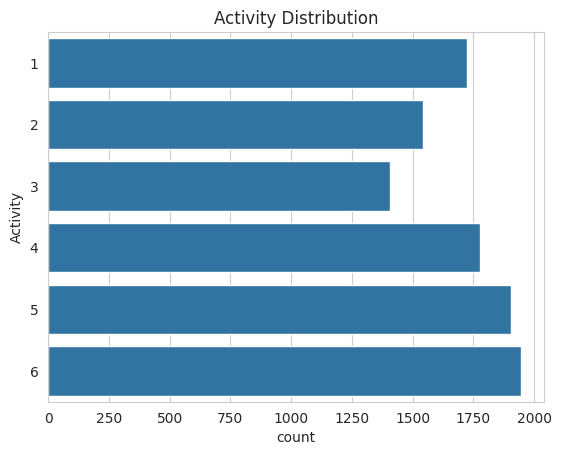

In [6]:
# checking how many samples per activity
sns.countplot(y='Activity', data=df)
plt.title("Activity Distribution")
plt.show()

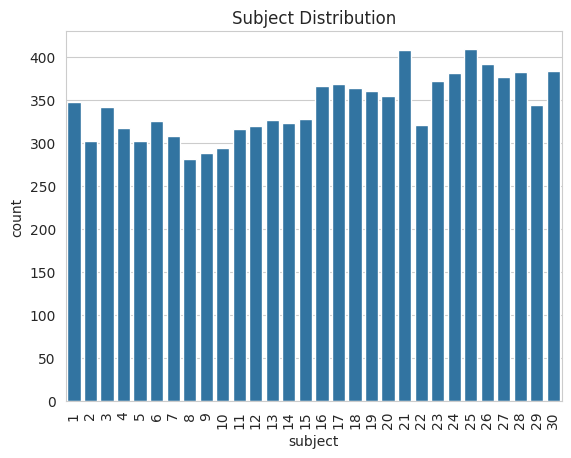

In [7]:
# checking data distribution across users
sns.countplot(x='subject', data=df)
plt.xticks(rotation=90)
plt.title("Subject Distribution")
plt.show()

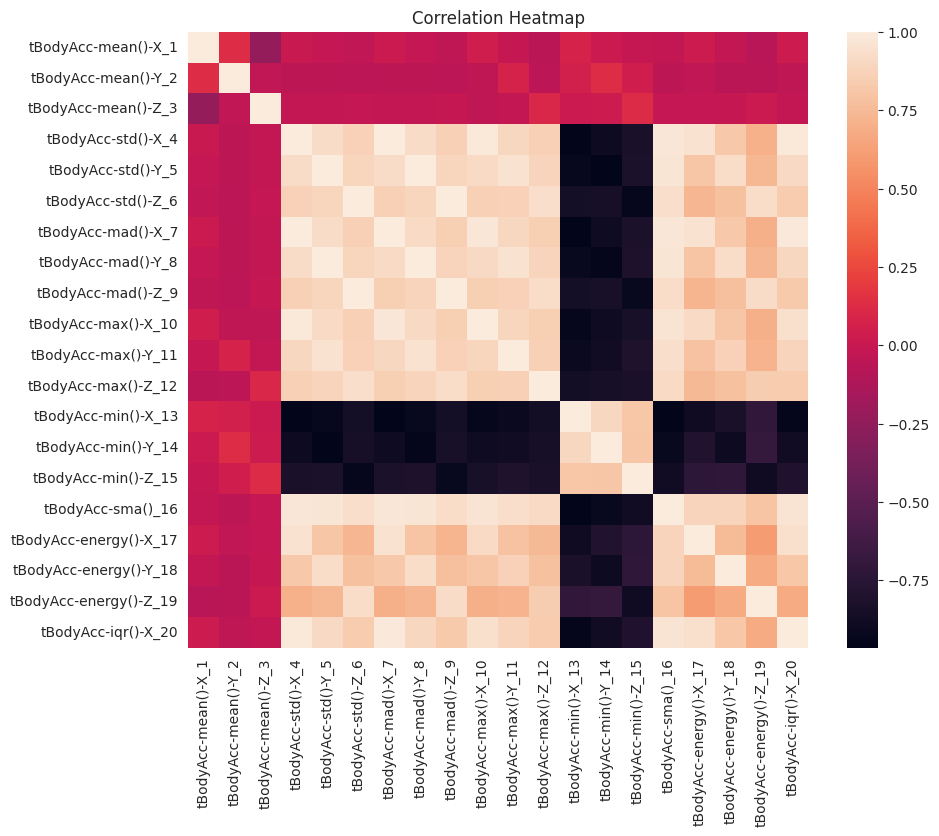

In [8]:
# checking relationship between features
subset = df.select_dtypes(include=np.number).iloc[:, :20]

plt.figure(figsize=(10,8))
sns.heatmap(subset.corr())
plt.title("Correlation Heatmap")
plt.show()

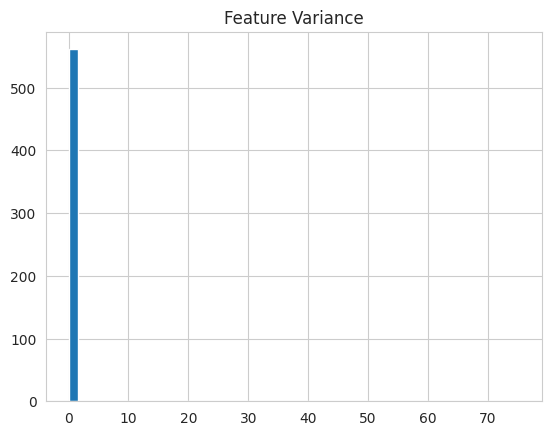

In [9]:
# checking which features vary more
variances = df.var(numeric_only=True)

plt.hist(variances, bins=50)
plt.title("Feature Variance")
plt.show()

In [10]:
# separating input and output
X = df.drop(columns=['Activity', 'subject'], errors='ignore')
y = df['Activity']

In [11]:
# scaling data so all features are equal
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
# reducing number of features
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print("Reduced shape:", X_pca.shape)

Reduced shape: (10299, 104)


In [13]:
# grouping similar data points
kmeans = KMeans(n_clusters=6, random_state=42)
clusters = kmeans.fit_predict(X_pca)

df['Cluster'] = clusters

In [14]:
# splitting data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

# training model
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [15]:
# predicting and checking accuracy
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
from sklearn.metrics import classification_report, confusion_matrix

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9422330097087379

Classification Report:

              precision    recall  f1-score   support

           1       0.96      0.98      0.97       369
           2       0.95      0.96      0.95       270
           3       0.96      0.93      0.95       284
           4       0.92      0.86      0.89       377
           5       0.88      0.92      0.90       354
           6       0.99      1.00      0.99       406

    accuracy                           0.94      2060
   macro avg       0.94      0.94      0.94      2060
weighted avg       0.94      0.94      0.94      2060


Confusion Matrix:

[[360   2   7   0   0   0]
 [  7 260   3   0   0   0]
 [  7  12 265   0   0   0]
 [  0   1   0 326  45   5]
 [  0   0   0  30 324   0]
 [  0   0   0   0   0 406]]


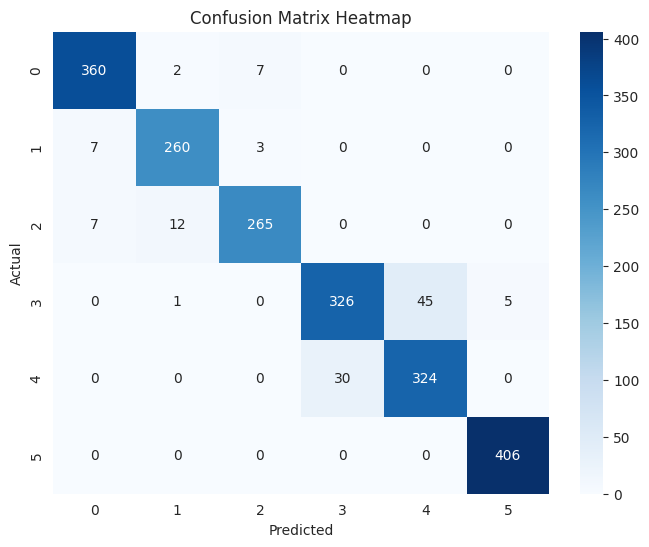

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")

plt.show()

## Final Conclusion

This project uses the Human Activity Recognition dataset to classify different human activities.

The dataset contains sensor-based features collected from smartphones.

Exploratory Data Analysis (EDA) was performed to understand the data distribution and relationships between features.

Feature scaling and PCA were applied to reduce dimensionality and improve model performance.

KMeans clustering was used to identify patterns in the data.

Finally, a Random Forest classifier was trained to predict activities.

The model achieved an accuracy of around 94%, which shows good performance.

The confusion matrix and classification report indicate that most activities are correctly classified.

This project demonstrates how machine learning can be used to recognize human activities using sensor data.